# Demo for PresentImages timing
VR Dec 11, 2025

In [1]:
import retinanalysis as ra
import matplotlib.pyplot as plt
import numpy as np

[2025-12-11 18:03:48,283][INFO]: DataJoint 0.14.4 connected to root@127.0.0.1:3306


Find and load dataset

In [2]:
df = ra.get_datasets_from_protocol_names('presentimages')
df.tail()


Found 1 protocols matching "presentimages":
['manookinlab.protocols.PresentImages']

Found 41 experiments, 122 epoch blocks.



,exp_name,datafile_name,NDF,chunk_name,protocol_name,is_mea,data_dir,group_label,experiment_id,protocol_id,group_id,block_id,chunk_id
117,20251015C,data001,1.0,present_images,manookinlab.protocols.PresentImages,1,20251015C/data001,Present Images FW10 + C2,165,16,2641,3986,691
118,20251015C,data004,0.0,present_images,manookinlab.protocols.PresentImages,1,20251015C/data004,Present Images FW0 + C2,165,16,2643,3988,691
119,20251022H,data004,4.0,present_images,manookinlab.protocols.PresentImages,1,20251022H/data004,present images 15 R*,168,16,2668,4024,704
120,20251022H,data012,2.0,present_images,manookinlab.protocols.PresentImages,1,20251022H/data012,present images 6 R*,168,16,2672,4032,704
121,20251106H,data005,4.0,natural_image,manookinlab.protocols.PresentImages,1,20251106H/data005,flashed natural images 4 R*,170,16,2684,4055,716


In [11]:
# Tested for couple datasets
# exp_name = '20250306C'
# datafile_name = 'data018'

exp_name = '20251015C'
datafile_name = 'data004'

sb = ra.MEAStimBlock(exp_name, datafile_name)
rb = ra.MEAResponseBlock(exp_name, datafile_name, b_load_fd=False)

Initializing StimBlock for 20251015C block 3988
Nearest noise chunk for data004 is chunk1 with distance 36 minutes.

Initializing ResponseBlock for 20251015C block 3988
Skipping loading frame monitor data.

Frame Monitor sample rate: 1000.0 Hz
Loading VCD from /Volumes/data-1/data/sorted/20251015C/data004/kilosort2.5 ...
VCD loaded with 560 cells.



I'm using the stim block's `regenerate_stimulus` method to get the onset and offset times of each image flash across epochs. The method calls each image flash a "trial".

In [17]:
help(ra.classes.stim.D_REGEN_FXNS['manookinlab.protocols.PresentImages'])

Help on function load_all_present_images in module retinanalysis.utils.regen:

load_all_present_images(df_epochs: pandas.core.frame.DataFrame, rb: retinanalysis.classes.response.MEAResponseBlock | retinanalysis.classes.response.SCResponseBlock, str_parent_path: str = None, ds_mu: float = 10.0, b_only_timing: bool = False) -> dict
    Load all unique flashed images and their onset/offset timing.
    
    Return dictionary with 'unique_images' array and 'image_names' list.
    
    Args:
        df_epochs (pd.DataFrame): Dataframe of epoch-block metadata.
        rb (MEAResponseBlock | SCResponseBlock): Responseblock with d_timing and amp_sample_rate
        str_parent_path (str, optional): Parent directory to images.
        ds_mu (float, optional): Downscale images to these um-sized pixels. Defaults to 10.0.
        b_only_timing (bool, optional): Return only transition timing. Defaults to False.
    
    Raises:
        ValueError: If multiple magnification factors are found across ep

In [18]:
sb.regenerate_stimulus(b_only_timing=True, rb=rb)

Regenerating stimulus for epochs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] in block: 3988
Using regeneration function: load_all_present_images
Using stage frame rate: 59.0 Hz
Using 13 pre frames, 59.0 Hz stage frame rate.
Protocol had 115 images per epoch, [6] flash frames, [24] gap frames.

Due to state.time duration and visibility controller, 3392 frames were visible.
But last image offset frame 3439 exceeds 3392 frames.
Epoch 0 thus only showed 113 images.
Assuming 113 is the correct number of images per epoch for all epochs.

Found 1150 unique images.
Found [1] repeats across all images.
These are named: ImageNet01/1.png - ImageNetTest/99.png
Average empirical frame rate: 59.9435 Hz
Regenerated stimulus with keys: ['all_image_paths', 'u_image_paths', 'repeats', 'trial_image_paths', 'trial_onset_samples', 'trial_offset_samples', 'trial_onset_ms', 'trial_offset_ms', 'trial_epoch_idx']


Text(0.5, 0, 'Time (ms)')

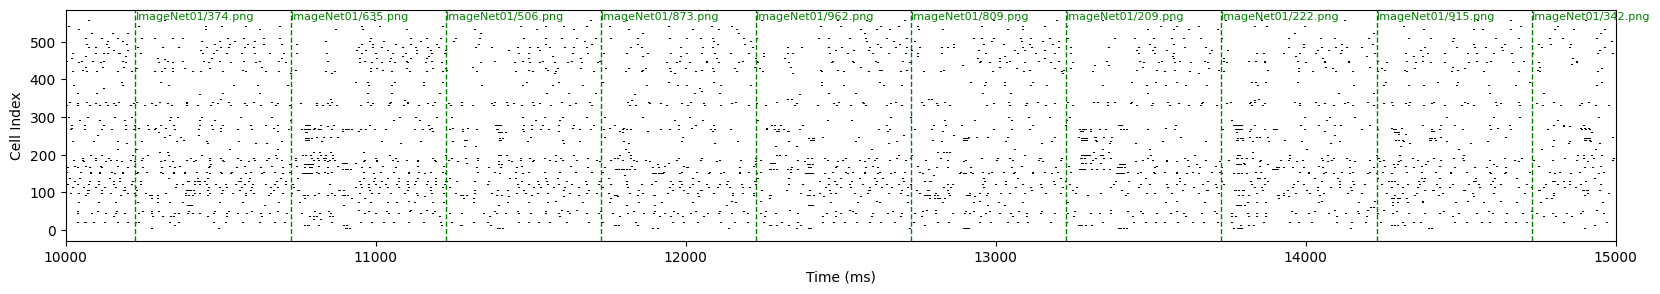

In [27]:
# Plot spike times for all cells and image onsets
d_stim = sb.stim_data

# Selecting first epoch and a time range
epoch_idx = 0
t_min = 10000
t_max = 15000

f, ax = plt.subplots(1, 1, figsize=(20, 3))
n_cells = len(rb.cell_ids)
for cell_idx in range(n_cells):
    sts = rb.df_spike_times.at[cell_idx,'spike_times'][epoch_idx]
    sts = [t for t in sts if t_min <= t <= t_max]
    ax.eventplot(sts, lineoffsets=cell_idx, linelengths=0.5, color='k')

epoch_trials = np.where(d_stim['trial_epoch_idx'] == epoch_idx)[0]
for trial_idx in epoch_trials:
    img_onset_ms = d_stim['trial_onset_ms'][trial_idx]
    img_offset_ms = d_stim['trial_offset_ms'][trial_idx]
    if img_onset_ms < t_min or img_offset_ms > t_max:
        continue
    ax.axvline(x=img_onset_ms, color='g', linestyle='--', lw=1)
    img_path = d_stim['trial_image_paths'][trial_idx]
    ax.text(img_onset_ms, n_cells, img_path, fontsize=8, color='g')
    # ax.axvline(x=img_offset_ms, color='k', linestyle='--', lw=1)

ax.set_xlim(t_min, t_max)
ax.set_ylabel('Cell Index')
ax.set_xlabel('Time (ms)')

TODO: Utility function for making PSTH of (cell, image trials, time)